# 07: Spatial barcode-transfer distance

Every cancer clone carries a unique lentiviral **barcode**. The barcode RNA does
not stay put — it is picked up by nearby cells, so a non-cancer cell next to a
barcoded cancer cell can end up reading that same barcode. This notebook measures
**how far a barcode travels from its cancer cell of origin**.

For each clone the barcode-positive cells split into **sender cells** (cancer) and
**receiver cells** (non-cancer); for every receiver we take the distance to the
nearest sender of the same clone. Two views follow:

* **Transfer probability** `g(r)` — of the non-cancer cells at distance `r` from a
  source, the fraction that carry the barcode (geometry-normalised, so it is a
  clean per-cell probability). It decays exponentially with distance.
* **Receiver spread** — how far the receivers that exist sit, decile by decile.

**Inputs** (place under `data/`, relative paths):
* `data/visium_{sample}_cells_final.h5ad` — segmented cells: `cell_id`,
  `obsm['spatial_fullres']` (centroids, full-res pixels), `obs['cell_type']`.
* `data/cell_barcode_{sample}.npz` — cell × barcode matrix (`cells`, `barcodes`,
  CSR `data/indices/indptr/shape`).


In [1]:
import numpy as np, pandas as pd, scipy.sparse as sp, anndata as ad
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.spatial import cKDTree
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

DATA = Path('data') if Path('data').exists() else Path('../data')   # repo-root or notebooks/
SAMPLES = ['1RR', '2N']
MPP = {'1RR': 0.7600241753442841, '2N': 0.7602646118307169}   # µm per full-res pixel
R_MAX, N_BINS = 400.0, 20                # decay window / distance bins (µm)
DBSCAN_EPS, DBSCAN_MIN = 80.0, 3         # drop isolated single-read barcode calls
TOP_N = 150                             # clones with the most receivers, for g(r)
SAMPLE_COLORS = {'1RR': '#0072B2', '2N': '#E69F00'}
FIT, NULL = '#D6604D', '#999999'
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12,
                     'axes.titlesize': 14, 'axes.labelsize': 12, 'xtick.labelsize': 10,
                     'ytick.labelsize': 10, 'legend.fontsize': 10, 'figure.titlesize': 15,
                     'axes.titleweight': 'normal', 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.facecolor': 'white',
                     'axes.facecolor': 'white'})
print('setup done')


setup done


## How `cell_barcode_{sample}.npz` is produced

The barcode table is built once by aggregating the raw 2 µm-bin barcode counts up
to segmented cells (bin → cell mapping from `barcode_mappings.parquet`). The
function below is the exact producer; it is skipped when the `.npz` is already
present, so **Run-All uses the provided file** and does not touch the multi-GB bin
matrices.


In [2]:
def build_cell_barcode_npz(sample):
    out = DATA / f'cell_barcode_{sample}.npz'
    if out.exists():
        return out                                   # provided -> nothing to do
    binh5 = ad.read_h5ad(DATA / f'visiumHD/{sample}/{sample}_square_002um.h5ad')
    labels_1read = binh5.obsm['labels_1read']        # (n_bins, n_barcodes), CSR
    barcodes = np.asarray(binh5.uns['labels_1read'])
    mp = pd.read_parquet(DATA / f'visiumHD/{sample}/barcode_mappings.parquet')
    mp = mp[mp.in_cell & mp.cell_id.notna()]
    cells, cell_idx = np.unique(mp.cell_id.values, return_inverse=True)
    cell_x_bin = sp.csr_matrix((np.ones(len(mp)), (cell_idx, mp.square_002um.values)),
                               shape=(len(cells), labels_1read.shape[0]))
    M = (cell_x_bin @ labels_1read).tocsr().astype('int32')     # cells × barcodes
    np.savez_compressed(out, cells=cells, barcodes=barcodes,
                        data=M.data, indices=M.indices, indptr=M.indptr, shape=M.shape)
    return out

for s in SAMPLES:
    build_cell_barcode_npz(s)      # no-op when the npz is provided
print('barcode tables ready')


barcode tables ready


## Load each sample

Everything the analysis needs is derived from the two input files: per-cell **µm
coordinates** (`spatial_fullres` × µm-per-pixel), the **cancer / non-cancer** call
(`cell_type == 'cancer'`), and the **cell × barcode** matrix — all aligned by
`cell_id`.


In [3]:
def load(sample):
    a = ad.read_h5ad(DATA / f'visium_{sample}_cells_final.h5ad', backed='r')
    cid = a.obs['cell_id'].astype(str).values
    xy_px = np.asarray(a.obsm['spatial_fullres'], dtype=float)
    is_cancer_all = a.obs['cell_type'].astype(str).values == 'cancer'
    a.file.close()

    z = np.load(DATA / f'cell_barcode_{sample}.npz', allow_pickle=True)
    M = sp.csr_matrix((z['data'], z['indices'], z['indptr']), shape=tuple(z['shape']))
    bc_cells = z['cells'].astype(str)
    barcodes = z['barcodes'].astype(str)

    pos = {c: i for i, c in enumerate(cid)}                     # align barcode rows -> h5ad
    rows = np.fromiter((pos.get(c, -1) for c in bc_cells), dtype=np.int64, count=len(bc_cells))
    ok = rows >= 0
    coords = xy_px[rows[ok]] * MPP[sample]                      # µm
    is_cancer = is_cancer_all[rows[ok]]
    M = M[ok]
    # per-barcode sender/receiver counts (for picking the biggest clones)
    Mb = (M > 0)
    n_send = np.asarray(Mb[is_cancer].sum(0)).ravel()
    n_recv = np.asarray(Mb[~is_cancer].sum(0)).ravel()
    return dict(coords=coords, is_cancer=is_cancer, M=M.tocsc(),
                barcodes=barcodes, n_send=n_send, n_recv=n_recv)

DATASETS = {s: load(s) for s in SAMPLES}
for s in SAMPLES:
    D = DATASETS[s]
    print(f"{s}: {len(D['coords']):,} cells  ·  {int(D['is_cancer'].sum()):,} cancer  ·  "
          f"{D['M'].shape[1]:,} barcodes")


1RR: 211,963 cells  ·  59,033 cancer  ·  16,999 barcodes
2N: 129,798 cells  ·  43,773 cancer  ·  12,352 barcodes


In [4]:
def clone_cells(D, col):
    """Sender (cancer) and receiver (non-cancer) cell indices for barcode column
    `col`, after a DBSCAN pass that drops isolated single-read calls."""
    rows = D['M'].getcol(col).nonzero()[0]
    if rows.size < 8:
        return None, None
    lab = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN).fit_predict(D['coords'][rows])
    keep = lab >= 0
    src = rows[keep & D['is_cancer'][rows]]
    rec = rows[keep & ~D['is_cancer'][rows]]
    return src, rec

def top_clone_cols(D, k, min_send=3, min_recv=5):
    elig = np.where((D['n_send'] >= min_send) & (D['n_recv'] >= min_recv))[0]
    return elig[np.argsort(D['n_recv'][elig])[::-1][:k]]


## Barcode transfer probability vs distance

For the 150 clones with the most receivers, bin all non-cancer cells by distance to
the nearest sender and take the fraction carrying the barcode in each bin — that is
`g(r)`. Averaged across clones (bootstrap 95 % CI) and fit with
`g(r) = A·e^(−r/λ) + c`. The **shuffled null** relabels the same number of receivers
at random and is essentially flat, so the decay is real. We report the half-distance
`λ·ln 2` (where the probability halves).


1RR: lambda = 63.6 um  (half-distance 44.1 um)  ·  146 clones
2N: lambda = 48.0 um  (half-distance 33.3 um)  ·  119 clones


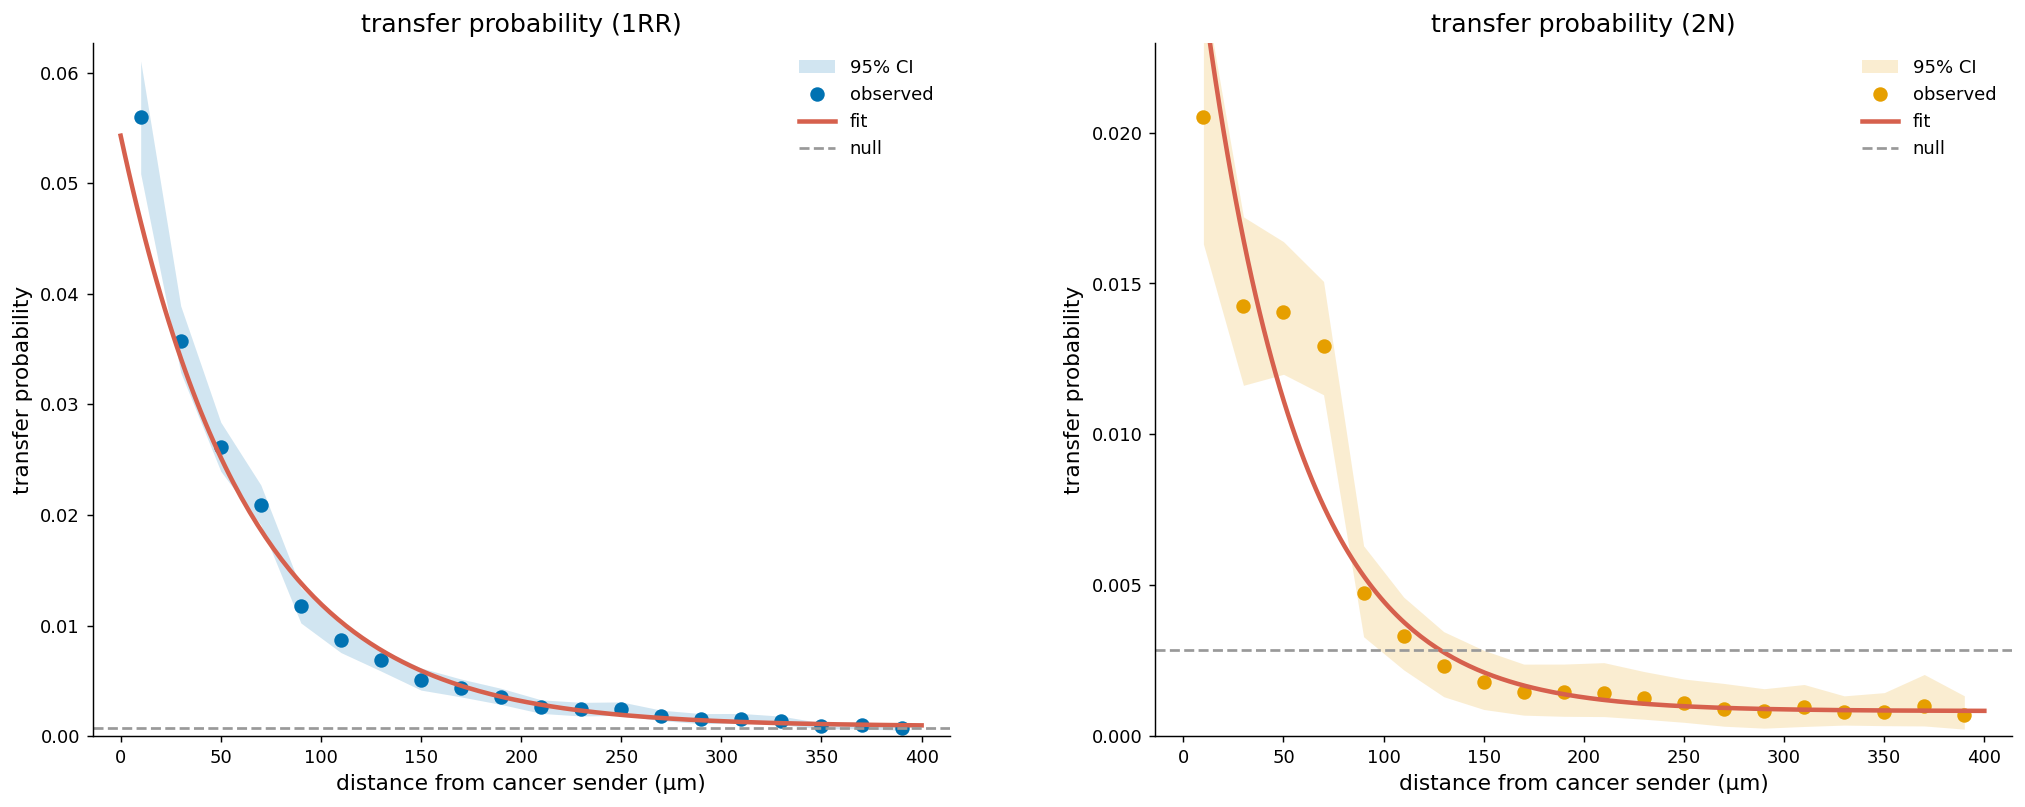

In [5]:
def decay_exp(r, A, lam, c):
    return A * np.exp(-r / lam) + c

def fit_decay(D):
    cols = top_clone_cols(D, TOP_N)
    noncancer = np.where(~D['is_cancer'])[0]
    nc_coords = D['coords'][noncancer]
    nc_pos = {m: i for i, m in enumerate(noncancer)}
    edges = np.linspace(0, R_MAX, N_BINS + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    rng = np.random.default_rng(0)
    rows_P, null_acc = [], []
    for col in cols:
        src, rec = clone_cells(D, col)
        if src is None or src.size < 3 or rec.size < 5:
            continue
        d_nc, _ = cKDTree(D['coords'][src]).query(nc_coords, k=1)
        which = np.clip(np.digitize(d_nc, edges) - 1, 0, N_BINS - 1)
        win = d_nc <= R_MAX
        tot = np.bincount(which[win], minlength=N_BINS).astype(float)
        rec_nc = np.array([nc_pos[m] for m in rec if m in nc_pos])
        is_rec = np.zeros(noncancer.size, bool); is_rec[rec_nc] = True
        with np.errstate(divide='ignore', invalid='ignore'):
            rows_P.append(np.where(tot > 0, np.bincount(which[win & is_rec], minlength=N_BINS) / tot, np.nan))
        perm = np.zeros(noncancer.size, bool)
        perm[rng.choice(noncancer.size, rec_nc.size, replace=False)] = True
        null_acc.append(np.where(tot > 0, np.bincount(which[win & perm], minlength=N_BINS) / tot, np.nan))
    P = np.vstack(rows_P); base = float(np.nanmean(np.vstack(null_acc)))
    mean = np.nanmean(P, axis=0)
    boots = np.array([np.nanmean(P[rng.integers(0, len(P), len(P))], 0) for _ in range(1000)])
    lo, hi = np.nanpercentile(boots, [2.5, 97.5], axis=0)
    ok = np.isfinite(mean) & (mean > 0)
    lm = lambda r, A, lam, c: np.log10(decay_exp(r, A, lam, c))
    f1 = lambda x, y: curve_fit(lm, x, np.log10(y), p0=[mean[ok][0], 80, base],
                                bounds=([0, 5, base * 0.2], [1, 1000, max(base * 3, 1e-6)]),
                                maxfev=20000)[0]
    A, lam, c = f1(centers[ok], mean[ok])
    lams = []
    for _ in range(500):
        m = np.nanmean(P[rng.integers(0, len(P), len(P))], 0); k = np.isfinite(m) & (m > 0)
        if k.sum() >= 4:
            try: lams.append(f1(centers[k], m[k])[1])
            except Exception: pass
    l_lo, l_hi = np.percentile(lams, [2.5, 97.5]) if lams else (np.nan, np.nan)
    return dict(centers=centers, mean=mean, lo=lo, hi=hi, base=base, A=A, lam=lam, c=c,
                l_lo=l_lo, l_hi=l_hi, n=len(P))

FITS = {s: fit_decay(DATASETS[s]) for s in SAMPLES}

fig, axes = plt.subplots(1, 2, figsize=(16.5, 6.4))
for ax, s in zip(axes, SAMPLES):
    f = FITS[s]; col = SAMPLE_COLORS[s]
    ax.fill_between(f['centers'], f['lo'], f['hi'], color=col, alpha=0.18, lw=0, label='95% CI')
    ax.plot(f['centers'], f['mean'], 'o', color=col, ms=7, label='observed')
    rr = np.linspace(0, R_MAX, 200)
    ax.plot(rr, decay_exp(rr, f['A'], f['lam'], f['c']), '-', color=FIT, lw=2.5, label='fit')
    ax.axhline(f['base'], color=NULL, ls='--', lw=1.5, label='null')
    ax.set_xlim(-14, R_MAX + 14); ax.set_ylim(0, np.nanmax(f['mean']) * 1.12)
    ax.set_xlabel('distance from cancer sender (µm)'); ax.set_ylabel('transfer probability')
    ax.set_title(f'transfer probability ({s})'); ax.legend(frameon=False, loc='upper right')
fig.tight_layout(); fig.subplots_adjust(wspace=0.24, left=0.08, right=0.975)
for s in SAMPLES:
    f = FITS[s]
    print(f"{s}: lambda = {f['lam']:.1f} um  (half-distance {f['lam']*np.log(2):.1f} um)  ·  {f['n']} clones")


## How far the barcoded receivers actually sit

The complementary view: across clones, the 10th–90th percentile of each clone's
receiver-to-nearest-sender distance. The median rises smoothly with percentile and
follows the quantile function of an exponential spread, `d(p) = d0 − λ·ln(1 − p)`.
`λ` here exceeds the per-cell probability's because more tissue (more candidate
cells) lies farther out.


1RR: lambda = 98.5 um  ·  488 clones
2N: lambda = 66.7 um  ·  156 clones


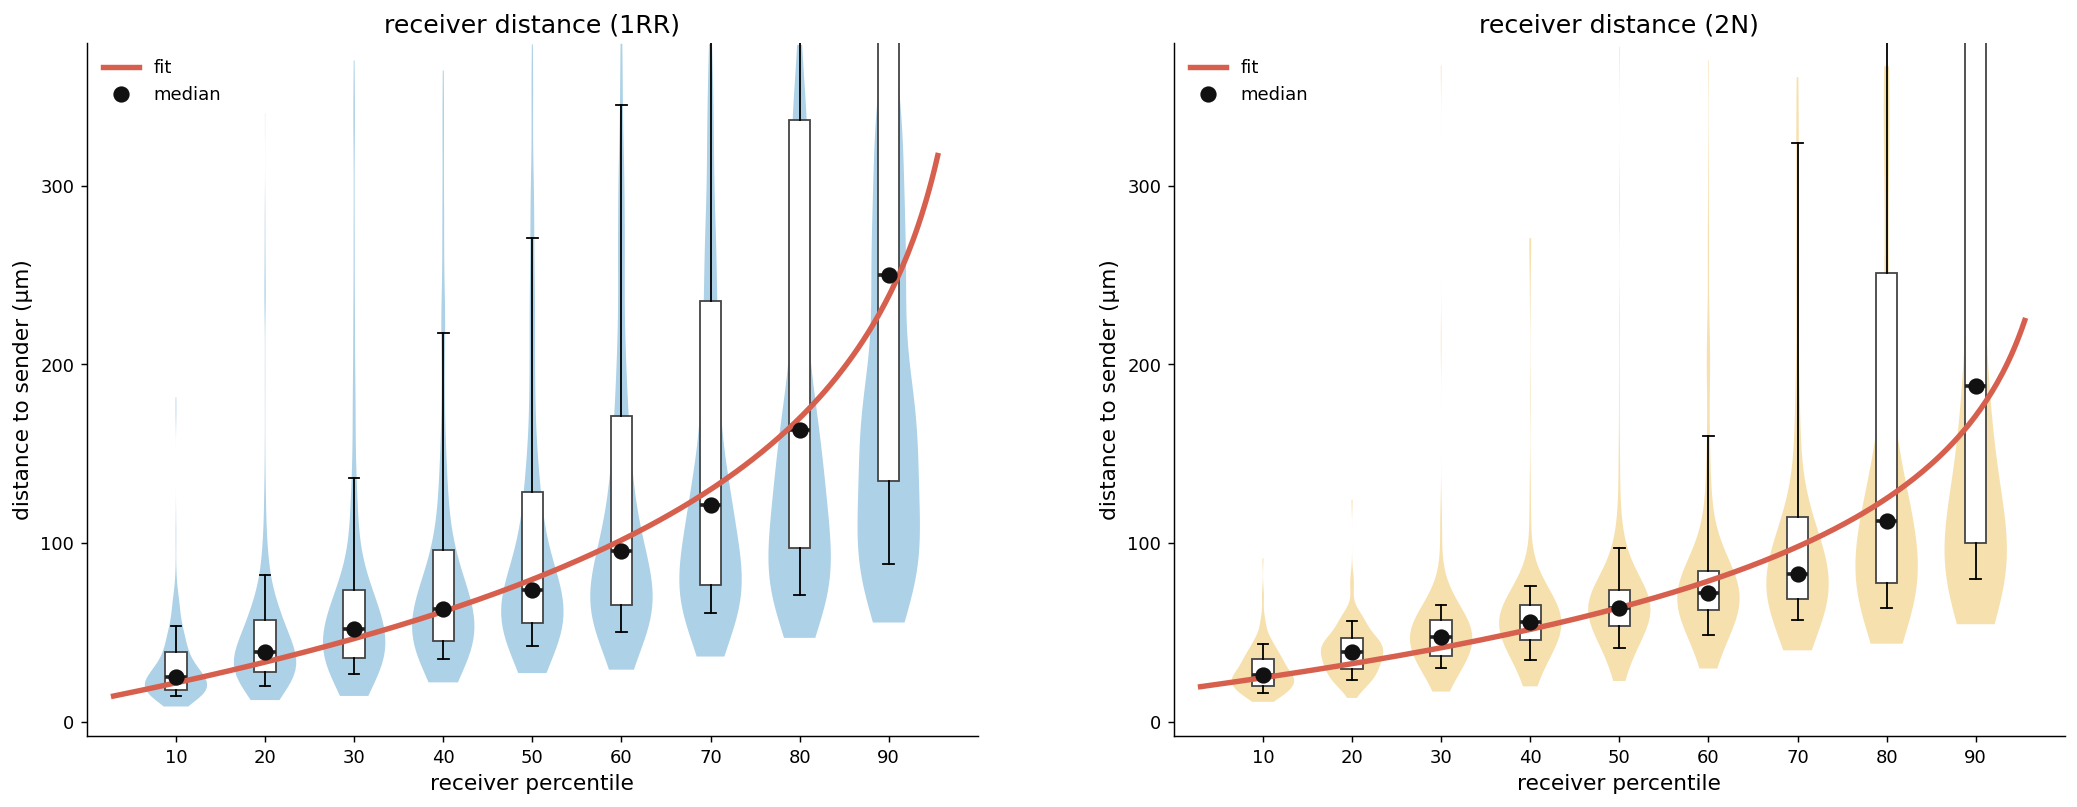

In [6]:
DECILES = np.arange(10, 100, 10)

def clone_deciles(D):
    rows = []
    for col in np.where((D['n_send'] >= 3) & (D['n_recv'] >= 10))[0]:
        src, rec = clone_cells(D, col)
        if src is None or src.size < 3 or rec.size < 10:
            continue
        d, _ = cKDTree(D['coords'][src]).query(D['coords'][rec], k=1)
        rows.append(np.percentile(d, DECILES))
    return np.array(rows)

def quantile_exp(p, lam, d0):
    return d0 - lam * np.log(1.0 - p)

fig, axes = plt.subplots(1, 2, figsize=(17, 6.4))
for ax, s in zip(axes, SAMPLES):
    Q = clone_deciles(DATASETS[s]); col = SAMPLE_COLORS[s]
    data = [Q[:, i][np.isfinite(Q[:, i])] for i in range(len(DECILES))]
    med = np.array([np.median(d) for d in data]); pp = DECILES / 100.0
    lam, d0 = curve_fit(quantile_exp, pp, med, p0=[80, 10],
                        bounds=([1, -200], [2000, 500]), maxfev=20000)[0]
    ycap = 380.0
    for b in ax.violinplot([d[d <= ycap] for d in data], positions=DECILES.astype(float),
                           widths=7.0, showextrema=False)['bodies']:
        b.set_facecolor(col); b.set_alpha(0.32); b.set_edgecolor('none')
    bp = ax.boxplot(data, positions=DECILES.astype(float), widths=2.4, showfliers=False,
                    whis=(10, 90), patch_artist=True, medianprops=dict(color='#222', lw=2),
                    manage_ticks=False)
    for patch in bp['boxes']:
        patch.set_facecolor('white'); patch.set_edgecolor('#444')
    rr = np.linspace(0.03, 0.955, 300)
    ax.plot(rr * 100, quantile_exp(rr, lam, d0), '-', color=FIT, lw=3, zorder=5, label='fit')
    ax.plot(DECILES, med, 'o', color='#111', ms=8, zorder=6, label='median')
    ax.set_ylim(-8, ycap); ax.set_yticks(np.arange(0, ycap + 1, 100))
    ax.set_xticks(DECILES); ax.set_xticklabels([str(p) for p in DECILES]); ax.set_xlim(0, 100)
    ax.set_xlabel('receiver percentile'); ax.set_ylabel('distance to sender (µm)')
    ax.set_title(f'receiver distance ({s})'); ax.legend(frameon=False, loc='upper left')
    print(f'{s}: lambda = {lam:.1f} um  ·  {len(Q)} clones')
fig.tight_layout(); fig.subplots_adjust(wspace=0.22, left=0.08, right=0.975)


## Representative clones in space

The four clones with the most receivers, on the tissue: every cell in light grey,
then the clone's **senders (cancer, red)** and **receivers (non-cancer, blue)**.
Senders and receivers sit intermingled within a compact niche.


drew 4 representative clones


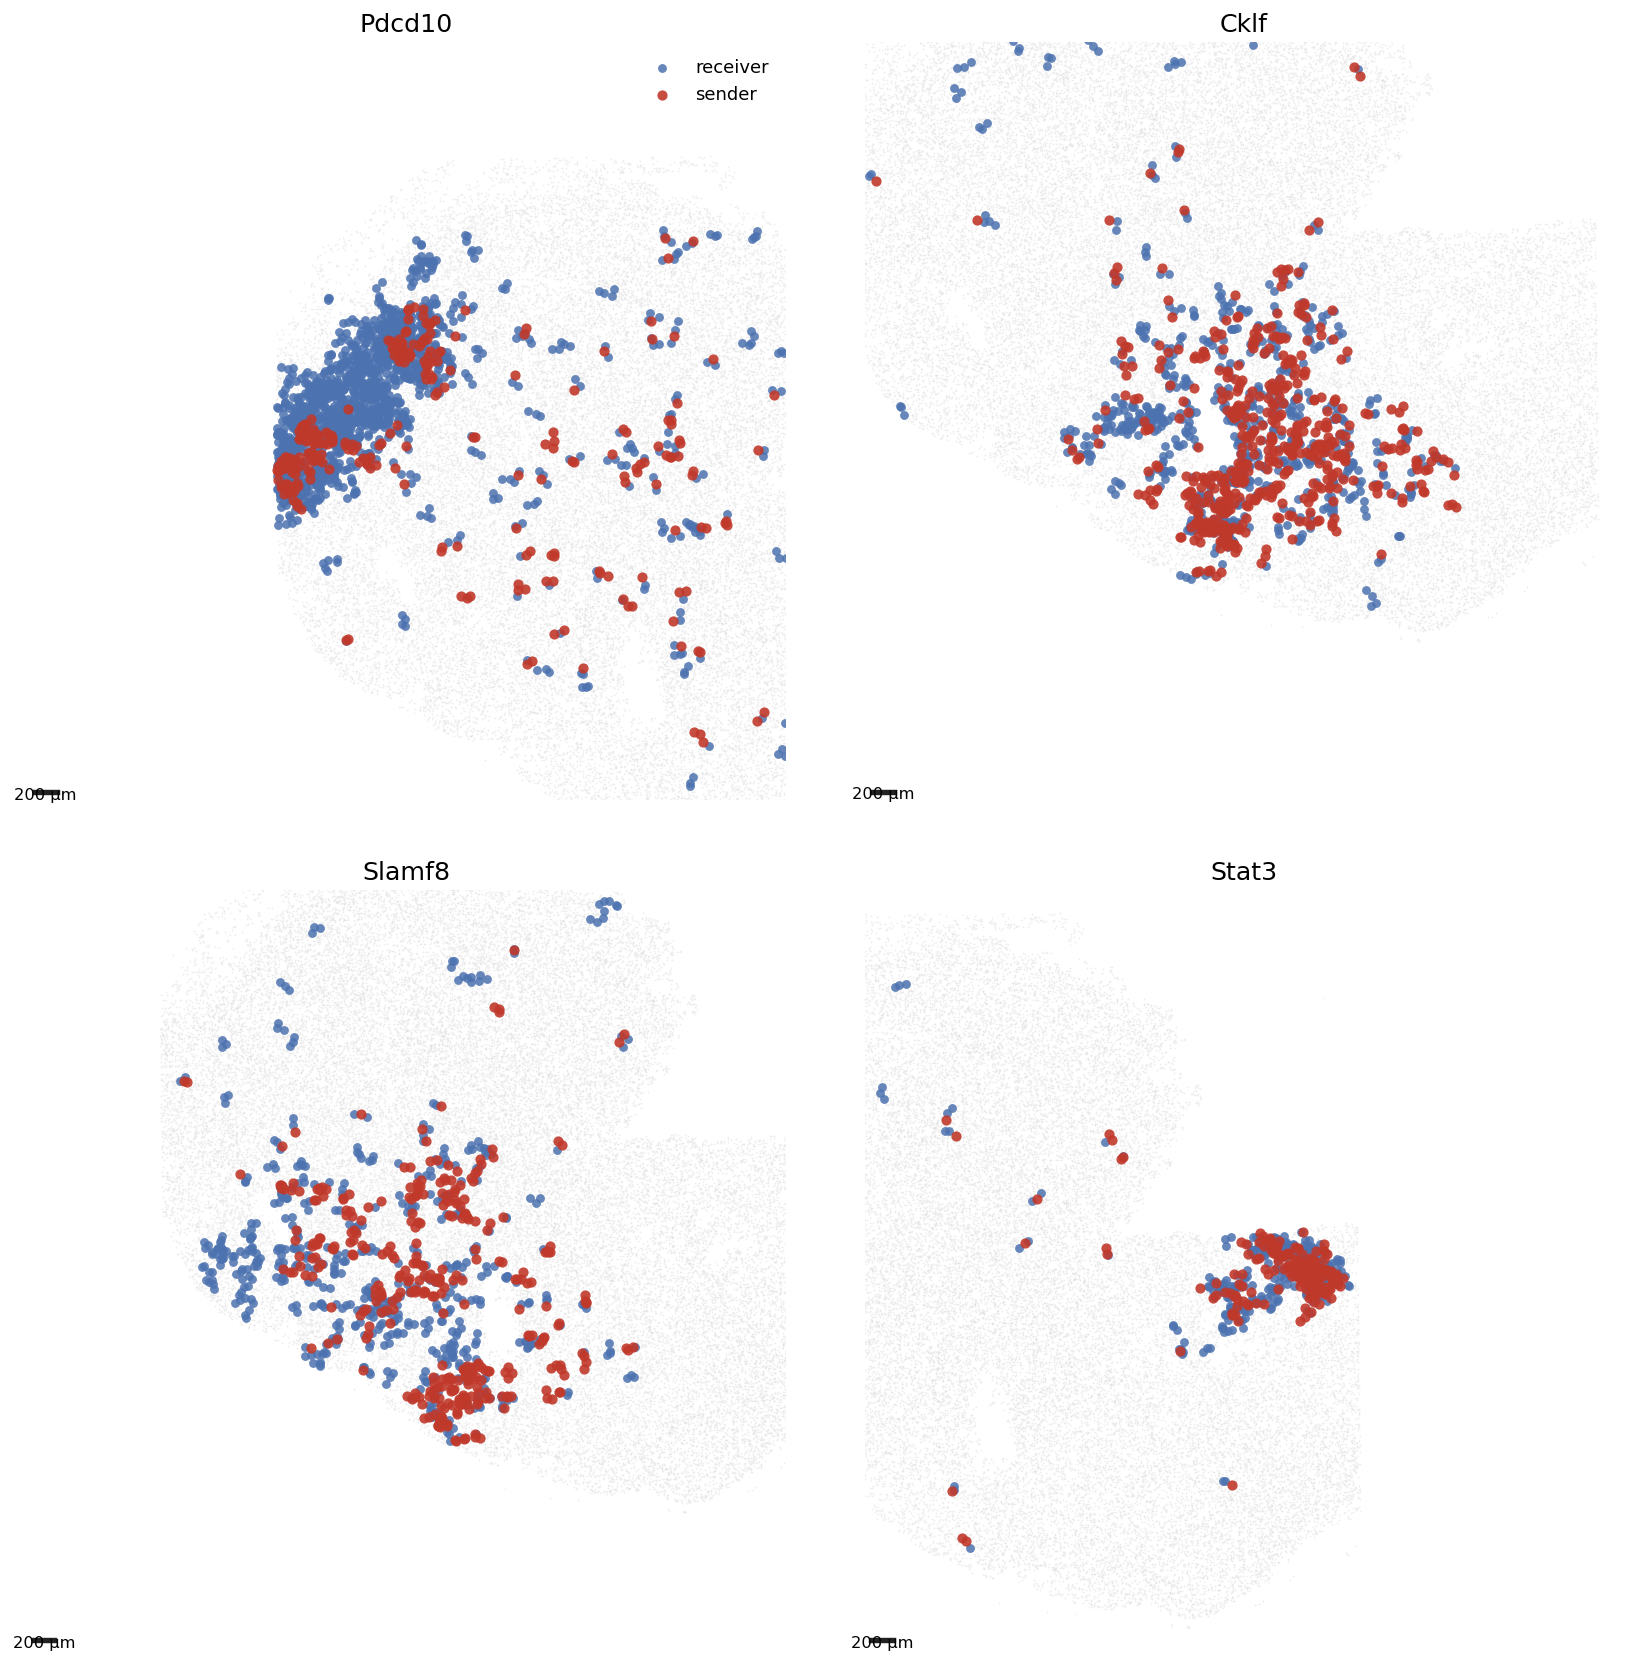

In [7]:
def clone_gene(D, col):
    return D['barcodes'][col].split('_', 1)[0]

s = '1RR'; D = DATASETS[s]
tops = list(top_clone_cols(D, 4))
rng = np.random.default_rng(0)
bg = rng.choice(len(D['coords']), size=min(40000, len(D['coords'])), replace=False)

fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for i, (ax, col) in enumerate(zip(axes.ravel(), tops)):
    src, rec = clone_cells(D, col)
    xy = D['coords'][np.concatenate([src, rec])]
    cx, cy = xy.mean(0)
    half = max(np.ptp(xy[:, 0]), np.ptp(xy[:, 1])) / 2 * 1.15 + 40
    ax.scatter(D['coords'][bg, 0], D['coords'][bg, 1], s=1, c='#dddddd', alpha=0.5, rasterized=True, lw=0)
    ax.scatter(D['coords'][rec, 0], D['coords'][rec, 1], s=24, c='#4C72B0', alpha=0.85, lw=0, label='receiver')
    ax.scatter(D['coords'][src, 0], D['coords'][src, 1], s=32, c='#C0392B', alpha=0.9, lw=0, label='sender')
    ax.set_xlim(cx - half, cx + half); ax.set_ylim(cy - half, cy + half)
    ax.set_aspect('equal'); ax.invert_yaxis(); ax.set_xticks([]); ax.set_yticks([])
    for sp_ in ax.spines.values():
        sp_.set_visible(False)
    ax.set_title(clone_gene(D, col))
    if i == 0:
        ax.legend(loc='upper right', frameon=False)
    ax.plot([cx - half + 60, cx - half + 260], [cy + half - 70] * 2, '-', color='#222', lw=3)
    ax.text(cx - half + 160, cy + half - 110, '200 µm', ha='center', va='top', fontsize=9)
fig.tight_layout(); fig.subplots_adjust(wspace=0.06, hspace=0.12)
print('drew', len(tops), 'representative clones')


---
Barcode transfer is a short-range, exponential process: the per-cell transfer
probability halves within a few tens of microns of a cancer sender, sits far above
the shuffled null near the source, and returns to background by ~300 µm.
